In [11]:
import os
import pandas as pd

os.makedirs("data", exist_ok=True)
if os.path.exists("sinh_vien.csv") and not os.path.exists("data/sinh_vien.csv"):
    os.rename("sinh_vien.csv", "data/sinh_vien.csv")

df = pd.read_csv("data/sinh_vien.csv")

nhom_tren_7 = df[df["diem_giua_ky"] >= 7.0]
so_luong_tren_7 = len(nhom_tren_7)

ty_le_qua_tren_7 = nhom_tren_7["qua_mon"].mean()

nhom_duoi_7 = df[df["diem_giua_ky"] < 7.0]
ty_le_qua_duoi_7 = nhom_duoi_7["qua_mon"].mean()

print(f"So ban co diem giua ky >= 7: {so_luong_tren_7}")
print(f"Ty le qua mon cua nhom >= 7: {ty_le_qua_tren_7:.4f}")
print(f"Ty le qua mon cua nhom duoi 7: {ty_le_qua_duoi_7:.4f}")

So ban co diem giua ky >= 7: 31
Ty le qua mon cua nhom >= 7: 0.9032
Ty le qua mon cua nhom duoi 7: 0.4831


Da luu do thi tai baitap02/sigmoid.png


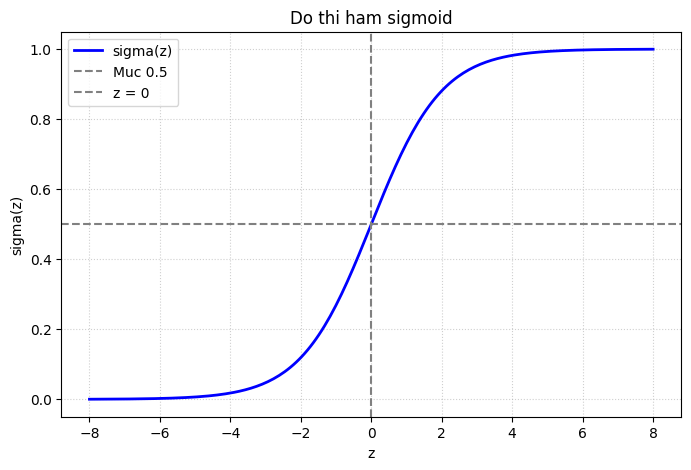

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)
sig = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, sig, label="sigma(z)", color="blue", linewidth=2)
plt.axhline(0.5, color="gray", linestyle="--", label="Muc 0.5")
plt.axvline(0, color="gray", linestyle="--", label="z = 0")

plt.xlabel("z")
plt.ylabel("sigma(z)")
plt.title("Do thi ham sigmoid")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

os.makedirs("baitap02", exist_ok=True)
plt.savefig("baitap02/sigmoid.png", dpi=300)
print("Da luu do thi tai baitap02/sigmoid.png")
plt.show()

In [13]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import numpy as np

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression().fit(X, y)
w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

def du_doan(gio):
    z = w * gio + b
    xac_suat = 1 / (1 + np.exp(-z))
    nhan = 1 if xac_suat >= 0.5 else 0
    print(f"So gio on: {gio:5.2f} | z = {z:6.2f} | Xac suat: {xac_suat:.4f} | Nhan: {nhan}")

print("Ket qua du doan cho cac ban cu the:")
for g in [3, 8, 12.89, 18, 26]:
    du_doan(g)

Ket qua du doan cho cac ban cu the:
So gio on:  3.00 | z =  -3.89 | Xac suat: 0.0201 | Nhan: 0
So gio on:  8.00 | z =  -1.92 | Xac suat: 0.1276 | Nhan: 0
So gio on: 12.89 | z =  -0.00 | Xac suat: 0.4996 | Nhan: 0
So gio on: 18.00 | z =   2.01 | Xac suat: 0.8814 | Nhan: 1
So gio on: 26.00 | z =   5.15 | Xac suat: 0.9942 | Nhan: 1


In [14]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
n = len(y_test)

accuracy = (tp + tn) / n
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

print("Tu tinh thu cong tu TP, TN, FP, FN:")
print(f"Accuracy  = {accuracy:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")
print(f"F1        = {f1:.4f}")

Tu tinh thu cong tu TP, TN, FP, FN:
Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947


In [15]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)
p = mo_hinh.predict_proba(X_test)[:, 1]

nguongs = np.arange(0.05, 1.0, 0.05)
best_f1 = -1
best_nguong = 0

print(f"{'Nguong':<10} {'F1 Score':<10}")
print("-" * 20)

for ng in nguongs:
    y_pred = (p >= ng).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f"{ng:<10.2f} {f1:<10.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_nguong = ng

print("-" * 20)
print(f"Nguong cho F1 cao nhat: {best_nguong:.2f} (F1 = {best_f1:.4f})")

Nguong     F1 Score  
--------------------
0.05       0.7826    
0.10       0.8182    
0.15       0.8182    
0.20       0.8571    
0.25       0.9000    
0.30       0.8947    
0.35       0.8947    
0.40       0.8947    
0.45       0.8947    
0.50       0.8947    
0.55       0.8889    
0.60       0.9412    
0.65       0.9412    
0.70       0.9091    
0.75       0.8750    
0.80       0.8387    
0.85       0.8000    
0.90       0.5600    
0.95       0.4348    
--------------------
Nguong cho F1 cao nhat: 0.60 (F1 = 0.9412)


In [16]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

pre_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
rec_0 = recall_score(y_test, y_pred, pos_label=0, zero_division=0)

print("Cham diem cho lop rot mon (lop 0):")
print(f"Precision = {pre_0:.4f}")
print(f"Recall    = {rec_0:.4f}")

Cham diem cho lop rot mon (lop 0):
Precision = 0.9000
Recall    = 0.7500
